## MAR "extreme" example

In [1]:
import importlib
import subprocess

def install_if_missing(package, import_name=None):
    name = import_name or package
    if importlib.util.find_spec(name) is None:
        subprocess.run(["pip", "install", package], check=True)

In [2]:

import os
import sys
import torch

from google.colab import drive
drive.mount('/content/drive')

install_if_missing("hyperimpute")

import sys
sys.path.insert(0, '/content/drive/My Drive/Colab Notebooks/WGF')

from pathlib import Path
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import argparse
import torch.nn as nn
import torch.optim as optim
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.transforms as transforms
from sklearn.metrics import mean_squared_error
from scipy.spatial.distance import cdist, pdist
import pandas as pd
import seaborn as sns
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import traceback
from flowgem import sample_flowgem
from hyperimpute.plugins.imputers import Imputers
from sklearn.impute import KNNImputer
import scipy
import time

base_path = "/content/drive/My Drive/Colab Notebooks/WGF"
sys.path.append(str(Path(f"{base_path}/MIRI-Imputation").resolve()))
from src.imputer_wrapper import impute_now

Mounted at /content/drive


### Set parameters and load existing results if available

In [13]:
### PARAMETER VALUES ###

param_vals = {
    ## Simulation params
    "n_runs": 20,

    ## Data params
    "n": 2000,
    "d": 3,
    "alpha": 0.7, #1 or 0.7
    "distr": "Normal", #UNI or Normal

    ## Resampling params
    "init": "ColBT",
    "T": 1000,
    "eta": 0.01
}
param_vals["n_new"] = param_vals["n"]

# Always leave truth
methods = ['truth', "knewimp"] # 'flowgem', 'mice', 'gain', 'hyperimpute', "miri",

save_all_iter = False

save_intermediate = False

In [14]:
# install R packages if necessary
if 'bayes' in methods:
    os.environ['RENV_CONFIG_AUTOLOAD_ENABLED'] = 'FALSE'
    os.environ['R_PROFILE_USER'] = ''
    import rpy2.robjects as ro
    from rpy2.robjects import pandas2ri
    from rpy2.robjects.packages import importr
    from rpy2.robjects.conversion import localconverter

    !apt-get install -y r-cran-mcmcpack
    !apt-get install -y r-cran-rfast

    !apt-get install -y r-cran-mcmcpack
    !apt-get install -y r-cran-rfast

    ro.r('''
        packages <- c("mvtnorm", "Rfast")
        for (pkg in packages) {
            if (!requireNamespace(pkg, quietly = TRUE)) {
                install.packages(pkg, repos="https://cloud.r-project.org")
            }
        }
    ''')

    ro.r(f'''
        source("{base_path}/Bayesian/Density_Estimation_Final.R")
        source("{base_path}/Bayesian/MHAlgorithm.R")
        source("{base_path}/Bayesian/helper.R")
    ''')

In [15]:
### CHECK WITH LOG FILE ###

# Define the log file path
save_dir = f"{base_path}/results/simulations/"
log_file = os.path.join(save_dir, 'parameter_log.csv')

# Check if the log file exists and read it
if os.path.exists(log_file):
    param_log = pd.read_csv(log_file)
else:
    param_log = pd.DataFrame(columns=['ID', 'n_runs',
                                      'n', 'd', 'alpha', 'distr',
                                      'init', 'n_new', 'T', 'eta'])

# Check if the parameter setup already exists in the log file
query_str = " & ".join([f"{k} == {repr(v)}" for k, v in param_vals.items()])
matching = param_log.query(query_str) #pd.DataFrame()

if not matching.empty:
    this_id = matching['ID'].iloc[0]
    # Load the existing results
    results_file = os.path.join(save_dir, f'results_{this_id}.pt')
    results = torch.load(results_file, weights_only=False)
    print(f"Setup already run under ID {this_id}")
else:
    # Determine the next ID
    if param_log.empty:
        this_id = 1
    else:
        this_id = param_log['ID'].max() + 1
    results_file = os.path.join(save_dir, f'results_{this_id}.pt')

    # Append to log file
    param_vals.update({'ID': this_id})
    param_log = pd.concat([param_log, pd.DataFrame([param_vals])], ignore_index=True)

    # Create new dict to save results
    results = {"data": {},
               "metrics": {},
               "Xhat_store": {}}

Setup already run under ID 2


### Generate simulated dataset (if not available)

In [16]:
def sample_x2_given_x1(X1):
    if param_vals["distr"] == "UNI":
        # conditional CDF: F(x2|x1) = x2 + alpha*(2*x1-1)*(x2^2 - x2)
        # invert this to sample X2 = F_inv(U)
        # Inversion yields quadratic equation: alpha*(2*x1-1)*x2^2 + [1 - alpha*(2*x1-1)]*x2 - u = 0
        # NOTE: CDF is symmetric so the same method can be used to sample X1 given X2
        U = np.random.rand(X1.shape[0])
        a = param_vals["alpha"] * (2*X1 - 1)
        b = 1 - a
        c = -U
        X2 = np.where(np.abs(a) < 1e-10, U/b, (-b + np.sqrt(b**2 - 4*a*c)) / (2*a))
    elif param_vals["distr"] == "Normal":
        X2 = np.random.multivariate_normal(param_vals["alpha"]*X1, (1-param_vals["alpha"]**2)*np.eye(X1.shape[0]))
    else:
        raise NotImplementedError("Chosen 'distr' is not implemented yet.")
    return X2

def sample_truth(n, d):
    if param_vals["distr"] == "UNI":
        X1 = np.random.rand(n)
        X2 = sample_x2_given_x1(X1)
        data = np.column_stack([X1, X2, np.random.rand(n, d-2)])
    elif param_vals["distr"] == "Normal":
        mu = np.zeros(d)
        cov = np.eye(d)
        cov[0,1] = param_vals["alpha"]
        cov[1,0] = param_vals["alpha"]
        data = np.random.multivariate_normal(mu, cov, n)
    else:
        raise NotImplementedError("Chosen 'distr' is not implemented yet.")

    Xdata = torch.from_numpy(data).to(device=device, dtype=torch.float64)
    X = Xdata[:n, :].detach().clone()
    return X

def impute_bootstrap_per_col(X, M):
    n, d = X.shape
    for j in range(d):
        observed_mask = M[:, j] == 1
        missing_mask = M[:, j] == 0

        observed_values = X[observed_mask, j]
        if observed_values.numel() == 0:
            raise ValueError(f"Value of column {j} is always missing. Need to be observed at least once.")

        num_missing = missing_mask.sum()
        if num_missing > 0:
            rand_idx = torch.randint(
                0, observed_values.shape[0],
                (num_missing,),
                device=X.device
            )
            X[missing_mask, j] = observed_values[rand_idx]

def generate_data(n, d, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Sample X
    X = sample_truth(n, d)
    Xstar = X.detach().clone()

    # Sample M
    if param_vals["distr"] == "UNI":
        X1 = X[:, 0]
        X2 = X[:, 1]
    elif param_vals["distr"] == "Normal":
        normal = torch.distributions.Normal(0.0, 1.0)
        X1 = normal.cdf(X[:, 0])
        X2 = normal.cdf(X[:, 1])
    else:
        raise NotImplementedError("Chosen 'distr' is not implemented yet.")
    P = torch.stack([(X1 + X2) / 3, (2 - X1) / 3, (1 - X2) / 3], dim=1)
    dist = torch.distributions.Categorical(P)
    choices = dist.sample()
    masks = torch.stack([torch.ones(d), torch.arange(d)!=1, torch.arange(d)!=0])
    M = masks[choices]

    # Substitute missing values with initial imputation
    if isinstance(param_vals["init"], (int, float)):
        X[M == 0] = param_vals["init"]
    elif param_vals["init"] == 'UNI(0,1)':
        X[M == 0] = torch.rand(n,d)[M == 0]
    elif param_vals["init"] == 'N(0.5,1)':
        X[M == 0] = torch.normal(mean=0.5, std=1, size=(n,d))[M == 0]
    elif param_vals["init"] == 'N(0,1)':
        X[M == 0] = torch.normal(mean=0, std=1, size=(n,d))[M == 0]
    elif param_vals["init"] == 'ColBT':
        impute_bootstrap_per_col(X, M)
    elif param_vals["init"] == "mice":
        Xmiss = X.clone()
        Xmiss[M == 0] = torch.nan
        imputer = Imputers().get("mice", max_iter=10)
        df = imputer.fit_transform(Xmiss.detach().numpy())
        X = torch.tensor(df.values, dtype=torch.float64)
    else:
        raise NotImplementedError("The chosen initial imputation method is not implemented.")

    return X.cpu(), M.cpu(), Xstar.cpu()

In [ ]:
if not results["data"]:
    for run in range(param_vals["n_runs"]):
        X0, M, Xstar = generate_data(param_vals["n"], param_vals["d"], seed=run)
        results["data"][run] = {"X0": X0,
                                "M": M,
                                "Xstar": Xstar}

### Run sample methods and compute metrics (only those that are not available yet)

In [ ]:
def energy_distance(X, Y):
    XY = cdist(X, Y)
    XX = cdist(X, X)
    YY = cdist(Y, Y)
    return (2 * XY.mean() - XX.mean() - YY.mean())* X.shape[0] / 2

def energy_distance_fixed_X(X, XX_mean, Y):
    XY_mean = cdist(X, Y).mean()
    n = len(Y)
    YY_mean = pdist(Y).mean() * (n - 1) / n
    return (2 * XY_mean - XX_mean - YY_mean)* X.shape[0] / 2

In [ ]:
def impute_truth(X0, M, n_imputations):
    X_imps = []
    for draw in range(n_imputations):
        Xhat = np.asarray(X0.detach().clone())
        Xhat[M[:,0] == 0, 0] = sample_x2_given_x1(X0[M[:,0] == 0, 1].detach().numpy())
        Xhat[M[:,1] == 0, 1] = sample_x2_given_x1(X0[M[:,1] == 0, 0].detach().numpy())
        Xhat = torch.from_numpy(Xhat)
        X_imps.append(Xhat)
    return X_imps

In [ ]:
for method in methods:
    if method in results["metrics"] and len(results["metrics"][method]) > 0:
        print(f"{method} already done — skipping")
        continue

    print(f"Running {method}")
    results["metrics"][method] = []

    for run, data in results["data"].items():
        indv_file = os.path.join(save_dir, f'indv/results_{this_id}_{method}_{run}.pt')
        if save_intermediate and os.path.exists(indv_file):
            print(f"{method} run {run+1} already done — skipping")
            continue

        print(f"Run number {run+1}")

        torch.manual_seed(run + param_vals["n_runs"])
        np.random.seed(run + param_vals["n_runs"])

        if method == "truth":
            start = time.time()
            Xhats = [sample_truth(param_vals["n_new"], param_vals["d"])]
            runtime = time.time() - start

        elif method == "true_impute":
            start = time.time()
            Xhats = impute_truth(data["X0"], data["M"], 1)
            runtime = time.time() - start

        elif method in ["miri", "missdiff", "knewimp"]:
            start = time.time()
            Xhats = [impute_now(data["X0"], data["M"].to(dtype=torch.float64), data["Xstar"], method, max_rounds=15, batchsize=500, maxepochs=900, odesteps=100)[0]]
            runtime = time.time() - start

        elif method in ["gain", "knn", "hyperimpute", "mice"]:
            Xmiss = data["X0"].clone()
            Xmiss[data["M"] == 0] = torch.nan
            if method == "knn":
                imputer = KNNImputer(n_neighbors=5)
            else:
                imputer = Imputers().get(method)
            start = time.time()
            X_imp = imputer.fit_transform(Xmiss.detach().numpy())
            runtime = time.time() - start
            Xhats = [torch.tensor(np.array(X_imp), dtype=torch.float64)]

        elif method == "flowgem":
            start = time.time()
            Xhats = sample_flowgem(data["X0"], data["X0"], data["M"], T=param_vals["T"],eta=param_vals["eta"], grad_tol=0.0001)
            runtime = time.time() - start

        elif method == "bayes":
            ro.r("set.seed(123)")
            ###Rundata and Xmiss are not defined
            # Convert pandas -> R
            Xmiss = data["X0"].clone()
            Xmiss[data["M"] == 0] = torch.nan
            X_df = pd.DataFrame(Xmiss.detach().numpy())
            X_df.columns = [f"x{i}" for i in range(X_df.shape[1])]
            with localconverter(ro.default_converter + pandas2ri.converter):
                r_df = ro.conversion.py2rpy(X_df)

            d = X_df.shape[1]
            n = X_df.shape[0]

            dp_gmm = ro.globalenv['dp_gmm_shared_Sigma']
            sample_pp = ro.globalenv['sample_posterior_predictive']

            start = time.time()
            tmp = dp_gmm(
                X=r_df,
                mu0=ro.FloatVector([0] * d),
                tau0_sq=d+1,
                nu0=d+2,
                Psi0=ro.r['diag'](d),
                niter= 800,
                nburn= 300
            )
            r_Xhats = sample_pp(tmp, n_pred=n)
            runtime = time.time() - start

            with localconverter(ro.default_converter + pandas2ri.converter):
                completed_df = ro.conversion.rpy2py(r_Xhats)

            X_imputed = torch.tensor(completed_df, dtype=torch.float64)
            Xhats = [X_imputed]

        else:
            raise NotImplementedError("Only methods 'truth' and 'wgf' implemented so far.")


        XX_star_mean = cdist(data["Xstar"], data["Xstar"]).mean()

        # Save immediately after each run
        if save_intermediate:
            run_result = {
                "Xhat": Xhats[-1],
                "metrics": {
                    "quantile": np.quantile(Xhats[-1], 0.1),
                    "energy": energy_distance_fixed_X(data["Xstar"], XX_star_mean, Xhats[-1]),
                    "energy.indep": energy_distance(results["Xhat_store"][f"truth_{run}"], Xhats[-1]),
                    "runtime": runtime
                }
            }
            torch.save(run_result, indv_file)
        else:
            Xid = f"{method}_{run}"
            results["Xhat_store"][Xid] = Xhats[-1]

            if save_all_iter:
                for i, Xhat in enumerate(Xhats):
                    results["metrics"][method].append({
                        "run": run,
                        "iter": i,
                        "quantile": np.quantile(Xhat, 0.1),
                        "energy": energy_distance_fixed_X(data["Xstar"], XX_star_mean, Xhat),
                        "energy.indep": energy_distance(results["Xhat_store"][f"truth_{run}"], Xhat)
                    })
                results["metrics"][method][-1]["runtime"] = runtime
            else:
                results["metrics"][method].append({
                    "quantile": np.quantile(Xhats[-1], 0.1),
                    "energy": energy_distance_fixed_X(data["Xstar"], XX_star_mean, Xhats[-1]),
                    "energy.indep": energy_distance(results["Xhat_store"][f"truth_{run}"], Xhats[-1]),
                    "runtime": runtime
                })

            results["metrics"][method][-1]["Xhat_id"] = Xid


Running truth
Run number 1
Running knewimp
Run number 1


/content/drive/.shortcut-targets-by-id/1sLNYIIYQEUf87cbk8nmnVbg-HDU4vagU/WGF/MIRI-Imputation/src/competitors/wgf_imp.py:213: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X, X_true = torch.tensor(X), torch.tensor(X_true)


Iteration 1:
Iteration 2:


/content/drive/.shortcut-targets-by-id/1sLNYIIYQEUf87cbk8nmnVbg-HDU4vagU/WGF/MIRI-Imputation/src/utils.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x, dtype = torch.float64, device=device)


### Save the results

In [87]:
# save_intermediate = True
# methods = ['bayes']
# param_vals = {'n_runs': 20}
# this_id = 2
# save_dir = f"{base_path}/results/simulations"

In [88]:
if not save_intermediate:
    # filename = f"results.{'.'.join(methods)}.{param_vals["distr"]}.pt"
    filename = os.path.join(save_dir, f'results_{this_id}.pt')
    torch.save(results, filename)

    # Save the updated log file
    param_log.to_csv(log_file, index=False)
    print(filename)
else:
    # Load existing aggregated results
    results_file = os.path.join(save_dir, f'results_{this_id}.pt')
    results = torch.load(results_file, weights_only=False)

    # Aggregate individual results
    for method in methods:
        if method not in results["metrics"]:
            results["metrics"][method] = []
        for run in range(param_vals["n_runs"]):
            result_file = os.path.join(save_dir, f'indv/results_{this_id}_{method}_{run}.pt')
            if os.path.exists(result_file):
                r = torch.load(result_file, weights_only=False)
                results["Xhat_store"][f"{method}_{run}"] = r["Xhat"]
                results["metrics"][method].append(r["metrics"])
                results["metrics"][method][-1]["Xhat_id"] = f"{method}_{run}"

    # Save updated aggregated results
    # torch.save(results, results_file)

In [ ]:
# filename = os.path.join(save_dir, 'results_1.pt')
# results = torch.load(filename, weights_only=False)
# param_vals["distr"] = "Normal"
# methods = ['truth', 'flowgem', 'mice', 'gain', 'hyperimpute']

### Plot the new complete samples

In [ ]:
# for run in range(param_vals['n_runs']):
#     X = results["Xhat_store"][f"bayes_{run}"]
#     plt.scatter(X[:, 0], X[:, 1], s=1)
#     plt.title(f"run={run}")
#     plt.show()

In [17]:
## Determine which run should be plotted
run = 1 if param_vals['distr'] == 'UNI' else 0

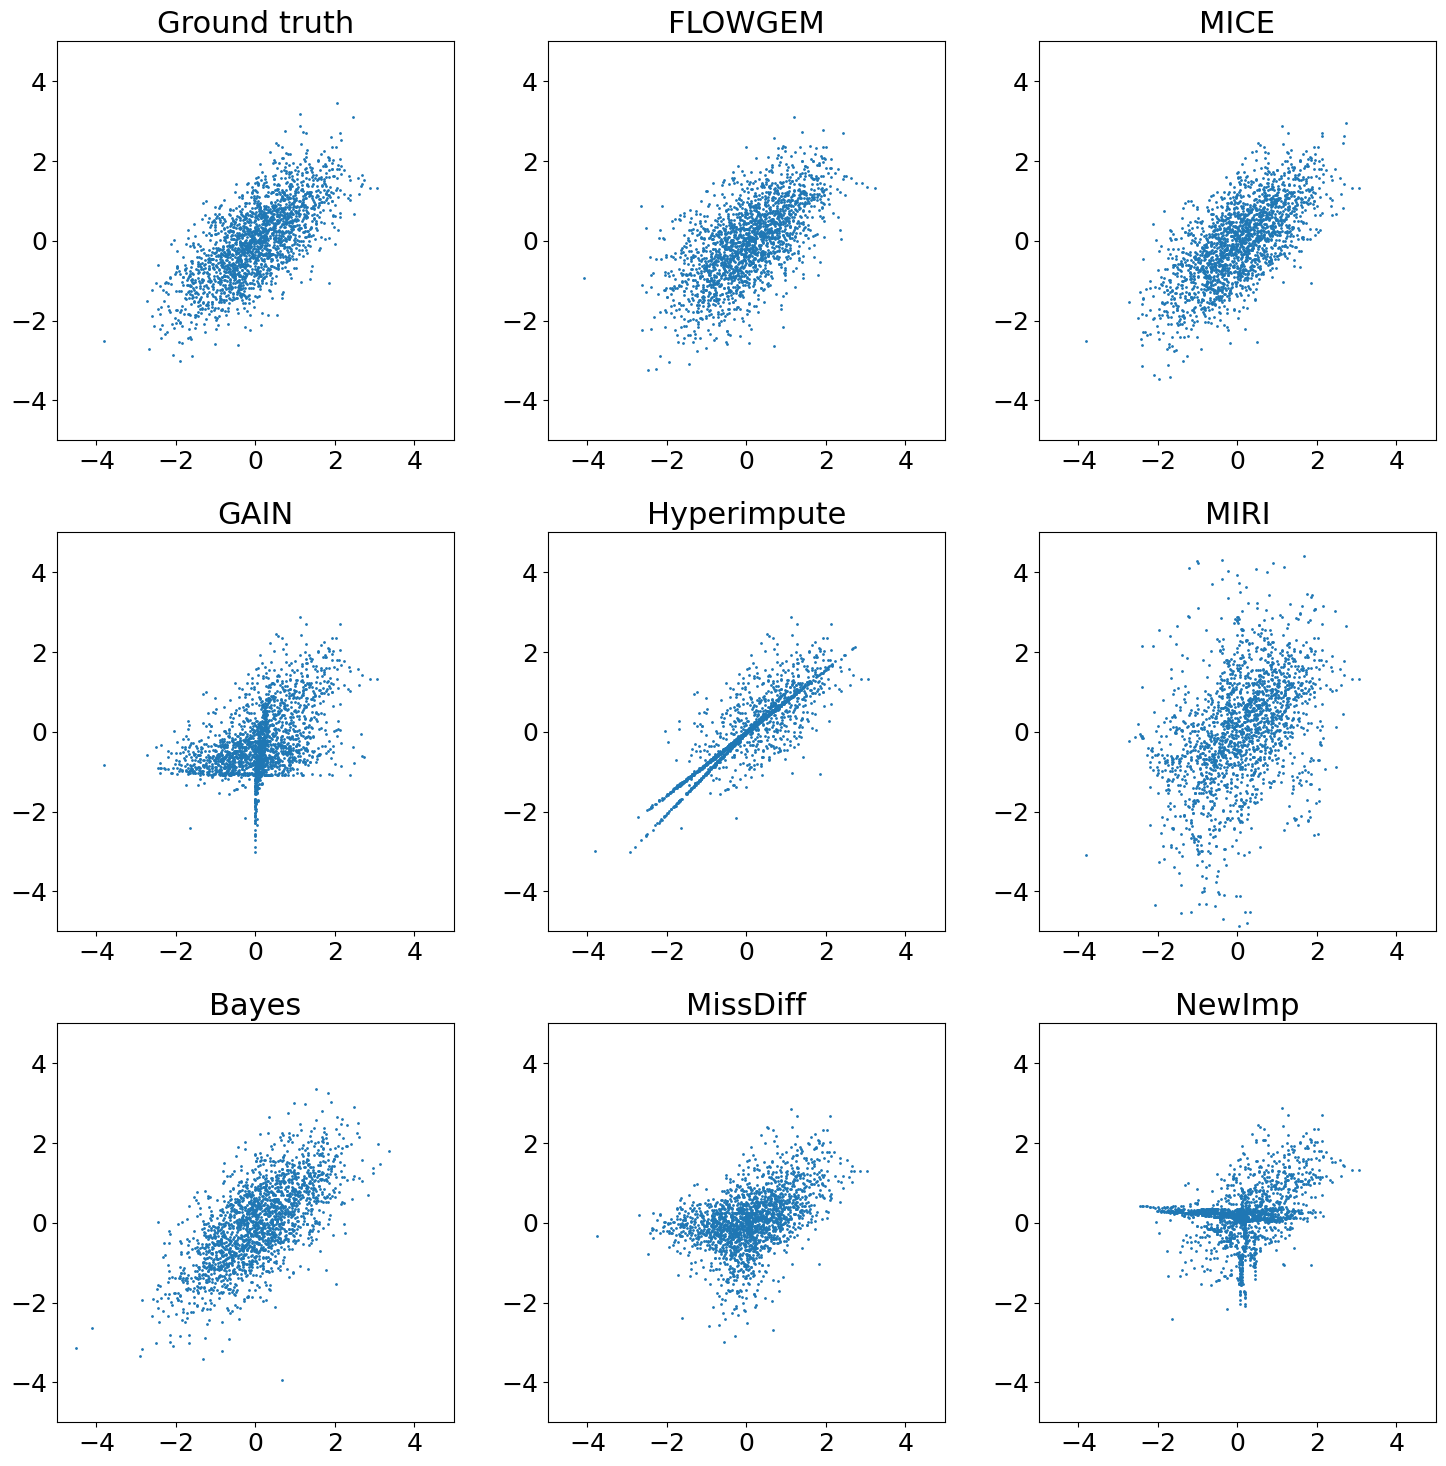

In [18]:
# methods_plot = [m for m in results['metrics'].keys() if m != "truth"]
methods_plot = ['flowgem', 'mice', 'gain', 'hyperimpute', 'miri', 'bayes', 'missdiff', 'knewimp']

plot_init = False

title_dict = {'gain': 'GAIN',
              'hyperimpute': 'Hyperimpute',
              'miri': 'MIRI',
              'bayes': 'Bayes',
              'flowgem': 'FLOWGEM',
              'mice': 'MICE',
              'missdiff': 'MissDiff',
              'knewimp': 'NewImp'}

titles = ["Ground truth", "Initial imputation"]

plt.rcParams.update({'font.size': 18})

# nrows = int(np.ceil((len(methods_plot)+2)/3))
# fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(15, 5*nrows))
if plot_init:
    fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
else:
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))
axes = axes.flatten()

if param_vals["distr"] == 'UNI':
    xymin = -0.75
    xymax = 1.75
else:
    xymin = -5
    xymax = 5

id_truth = 1 if plot_init else 0
Xstar = results["data"][run]["Xstar"]
axes[id_truth].scatter(Xstar[:, 0].cpu(), Xstar[:, 1].cpu(), s=1)
axes[id_truth].set_xlim(xymin, xymax)
axes[id_truth].set_ylim(xymin, xymax)
axes[id_truth].set_title(titles[0], fontsize=22)

if plot_init:
    X0 = results["data"][run]["X0"]
    axes[2].scatter(X0[:, 0].detach().cpu(), X0[:, 1].detach().cpu(), s=1)
    axes[2].set_xlim(xymin, xymax)
    axes[2].set_ylim(xymin, xymax)
    axes[2].set_title(titles[1], fontsize=22)

for i, method in enumerate(methods_plot):
    id_meth = i+4 if plot_init else i+1
    X = results["Xhat_store"][f"{method}_{run}"]
    axes[id_meth].scatter(X[:, 0], X[:, 1], s=1)
    axes[id_meth].set_xlim(xymin, xymax)
    axes[id_meth].set_ylim(xymin, xymax)
    axes[id_meth].set_title(title_dict[method], fontsize=22)

if param_vals['distr'] == 'UNI':
    for ax in axes:
        rect = plt.Rectangle((0, 0), 1, 1, linewidth=1, edgecolor='black', facecolor='none')
        ax.add_patch(rect)

# for j in range(len(methods_plot) + 2, len(axes)):
if plot_init:
    for j in [0,3]:
        axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(f"{base_path}/results/simulations/imputations{param_vals["distr"]}.png", dpi=150, bbox_inches="tight")
plt.show()

## Boxplots for RMSE, Energy and Quantile

In [19]:
## Create dataframe with all results
rows = []
for method, recs in results["metrics"].items():
    for r in recs:
        rows.append({**r, "method": method})

results_df = pd.DataFrame(rows)

/tmp/ipykernel_11723/4079506995.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="method", y=col, data=df_max, ax=ax, showfliers=False, palette=make_palette(df_max))
/tmp/ipykernel_11723/4079506995.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="method", y=col, data=df_max, ax=ax, showfliers=False, palette=make_palette(df_max))
/tmp/ipykernel_11723/4079506995.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([title_dict[tick.get_text()] for tick in ax.get_xticklabels()])
/tmp/ipykernel_11723/4079506995.py:56: UserWarning: set_ticklabels() should only be used with a f

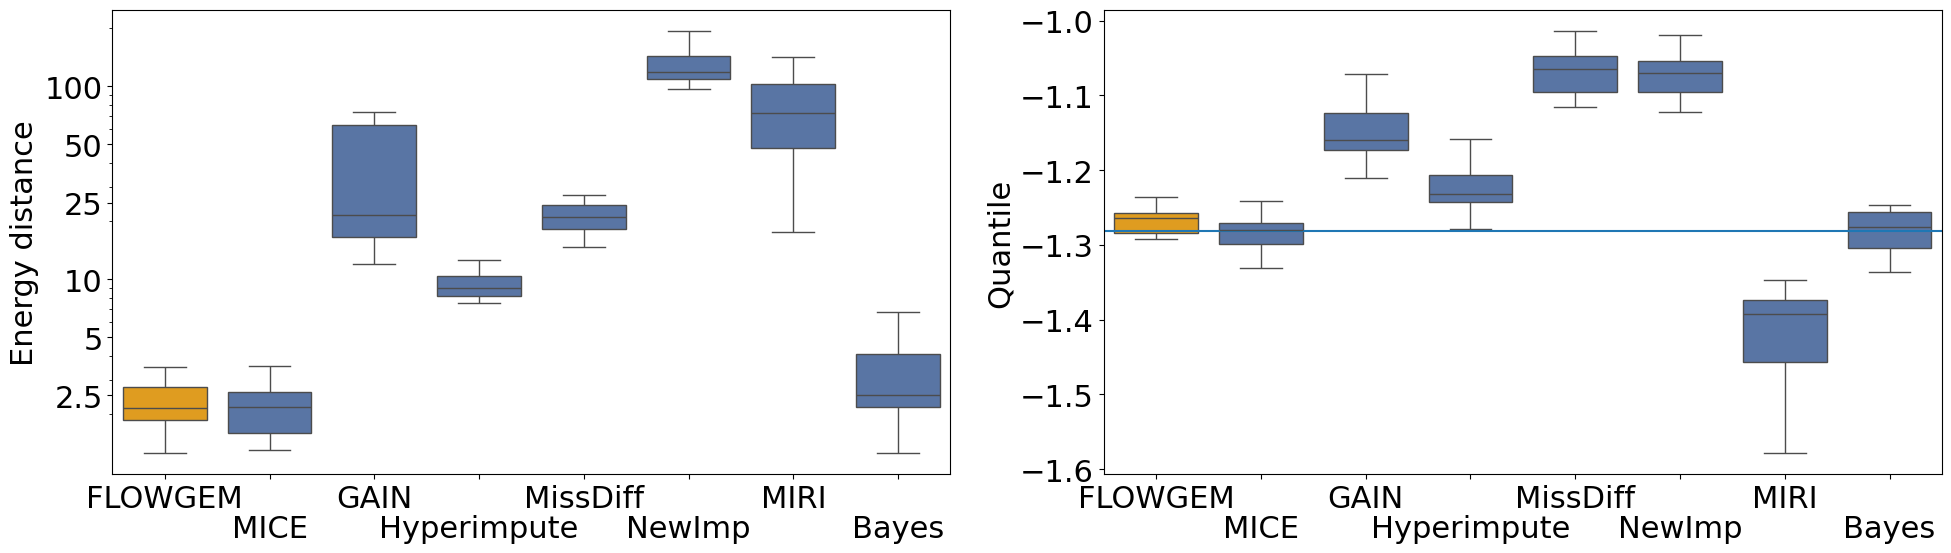

In [20]:
def boxplot(df, col, only_wgf=False, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    if only_wgf:
        if not save_all_iter:
            raise NotImplementedError("Only the final results were saved. Cannot plot results per iteration.")
        sns.boxplot(x="iter", y=col, data=df[df["method"] == "flowgem"], ax=ax)
        ax.set_xlabel("WGF Iteration")
        ax.set_title(f"{col} distribution per iteration")
    else:
        if save_all_iter:
            idx = df.groupby(['method', 'run'])['iter'].idxmax()
            df_max = df.loc[idx].reset_index(drop=True)
        else:
            df_max = df

        def make_palette(df, col="method", highlight="flowgem", highlight_color="orange", default_color="#4C72B0"):
            methods = df[col].unique()
            return {m: highlight_color if m == highlight else default_color for m in methods}
        sns.boxplot(x="method", y=col, data=df_max, ax=ax, showfliers=False, palette=make_palette(df_max))
        ax.set_xlabel("")
        #ax.set_title(f"{col} distribution per method")
    ax.set_ylabel(col)
    if col == "quantile":
        if param_vals["distr"] == "UNI":
            ax.axhline(0.1)
            ax.axhline(0.106, linestyle='--')
        elif param_vals["distr"] == "Normal":
            ax.axhline(scipy.stats.norm.ppf(0.1))

    if ax is None:
        plt.show()

plt.rcParams.update({'font.size': 22})

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, col in zip(axes, ["energy.indep", "quantile"]):
    boxplot(results_df[results_df["method"] != "truth"], col, ax=ax)

axes[0].set_ylabel("Energy distance")
axes[1].set_ylabel("Quantile")

axes[0].set_yscale("log")
if param_vals["distr"] == 'UNI':
    axes[0].set_yticks([0.5, 1, 2.5, 5, 10, 25, 50, 100], [0.5, 1, 2.5, 5, 10, 25, 50, 100])
    axes[0].set_ylim(bottom=0.25, top=110)
    axes[1].set_ylim(bottom=0.05, top=0.15)
else:
    axes[0].set_yticks([2.5, 5, 10, 25, 50, 100], [2.5, 5, 10, 25, 50, 100])
    # axes[0].set_ylim(bottom=1.25, top=500)


axes[0].set_xticklabels([title_dict[tick.get_text()] for tick in ax.get_xticklabels()])
axes[1].set_xticklabels([title_dict[tick.get_text()] for tick in ax.get_xticklabels()])

# Offset every other label downward
for k in [0,1]:
  for i, label in enumerate(axes[k].get_xticklabels()):
      if i % 2 != 0:  # every other label
          label.set_transform(label.get_transform() +
                              transforms.ScaledTranslation(0, -0.3, fig.dpi_scale_trans))

plt.tight_layout()
plt.savefig(f"{base_path}/results/simulations/boxplots{param_vals["distr"]}.png", dpi=150, bbox_inches="tight")
plt.show()

In [60]:
from statistics import median
energy_miri = [r['energy.indep'] for r in results['metrics']['miri']]
print(min(energy_miri))
print(max(energy_miri))
print(median(energy_miri))

6.374973967293918
4.7876495817992463e+148
2.021758339515282e+46


In [61]:
from statistics import median
energy_miri = [r['quantile'] for r in results['metrics']['miri']]
print(min(energy_miri))
print(max(energy_miri))
print(median(energy_miri))

-2.9476175523291492
0.13048560129402492
0.08601233591176227


In [73]:
def summary_table_latex(df, col, methods_order=None):
    def fmt(x):
        return f"{x:.2f}"

    summary = df.groupby("method")[col].agg(["mean", "std"])

    if methods_order is not None:
        summary = summary.loc[methods_order]

    if title_dict is not None:
        summary = summary.rename(index=title_dict)

    summary["mean"] = summary["mean"].map(fmt)
    summary["std"] = summary["std"].map(fmt)

    summary = summary.rename(columns={"mean": "Mean", "std": "Std. Dev."})
    summary.index.name = "Method"

    print(summary.to_latex(escape=False))

summary_table_latex(results_df[results_df["method"] != "truth"], "runtime", methods_order=methods_plot)

\begin{tabular}{lll}
\toprule
 & Mean & Std. Dev. \\
Method &  &  \\
\midrule
FLOWGEM & 22.85 & 1.36 \\
MICE & 0.56 & 0.00 \\
GAIN & 2.80 & 0.64 \\
Hyperimpute & 8.68 & 5.63 \\
MIRI & 1611.91 & 2588.70 \\
Bayes & 2038.28 & 520.23 \\
MissDiff & 19.22 & 1.03 \\
NewImp & 18.16 & 0.56 \\
\bottomrule
\end{tabular}

